### Student Name: Hilton Sarius
### Course: MAI5301 - Foundations Of Large Language Models
### Activity: Assigment #2

In [616]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

In [617]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


### Simple Self-Attention Implementation

In [618]:
tokens = ["Your", "journey", "starts", "with", "one", "step"]

In [619]:
vocab = dict(zip(tokens, range(len(tokens))))
input_ids = torch.tensor(list(map(lambda t: vocab[t], tokens)))

embedding = nn.Embedding(len(vocab), 3)
inputs = embedding(input_ids)

print("inputs shape:", inputs.shape)
print("inputs:\n", inputs)

inputs shape: torch.Size([6, 3])
inputs:
 tensor([[-1.3351,  1.6516, -1.4236],
        [-0.6961, -0.3182,  1.2154],
        [ 1.4200, -0.0547,  0.0247],
        [-1.0641, -0.3639, -0.0993],
        [ 0.3105,  0.3715,  0.2697],
        [ 0.7900,  0.9446, -1.5824]], grad_fn=<EmbeddingBackward0>)


In [620]:
# Attention scores
attn_scores = torch.matmul(inputs, inputs.T)

print("Unnormalized Attention Scores:\n", attn_scores)

# Attention weights
attn_weights = torch.softmax(attn_scores, dim=-1)

print("\nNormalized Attention Weights:\n", attn_weights)
print("Row sums:", attn_weights.sum(dim=-1))

# Context vectors
context_vectors = torch.matmul(attn_weights, inputs)

print("\nContext Vectors:\n", context_vectors)


Unnormalized Attention Scores:
 tensor([[ 6.5368, -1.3265, -2.0212,  0.9611, -0.1850,  2.7581],
        [-1.3265,  2.0631, -0.9410,  0.7358, -0.0066, -2.7738],
        [-2.0212, -0.9410,  2.0199, -1.4936,  0.4273,  1.0311],
        [ 0.9611,  0.7358, -1.4936,  1.2747, -0.4924, -1.0272],
        [-0.1850, -0.0066,  0.4273, -0.4924,  0.3071,  0.1694],
        [ 2.7581, -2.7738,  1.0311, -1.0272,  0.1694,  4.0204]],
       grad_fn=<MmBackward0>)

Normalized Attention Weights:
 tensor([[9.7236e-01, 3.7395e-04, 1.8669e-04, 3.6840e-03, 1.1710e-03, 2.2220e-02],
        [2.2744e-02, 6.7446e-01, 3.3442e-02, 1.7887e-01, 8.5136e-02, 5.3496e-03],
        [1.0497e-02, 3.0917e-02, 5.9718e-01, 1.7791e-02, 1.2146e-01, 2.2215e-01],
        [2.7600e-01, 2.2033e-01, 2.3705e-02, 3.7766e-01, 6.4515e-02, 3.7791e-02],
        [1.2761e-01, 1.5253e-01, 2.3540e-01, 9.3836e-02, 2.0874e-01, 1.8189e-01],
        [2.0777e-01, 8.2243e-04, 3.6943e-02, 4.7167e-03, 1.5608e-02, 7.3414e-01]],
       grad_fn=<SoftmaxBackw

In [621]:
def plot_attention_weights(weights, tokens):
    weights = weights.detach().cpu()

    fig, ax = plt.subplots(figsize=(8, 6))
    cax = ax.imshow(weights, cmap="viridis")
    fig.colorbar(cax)

    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=45, ha="right")
    ax.set_yticklabels(tokens)

    ax.set_xlabel("Keys (Attended to)")
    ax.set_ylabel("Queries (Focusing)")
    ax.set_title("Self-Attention Weights")

    # Highlight max attention per row
    for i in range(weights.size(0)):
        j = torch.argmax(weights[i]).item()
        ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1,
                                   fill=False, edgecolor='red', lw=2))

    plt.tight_layout()
    plt.show()


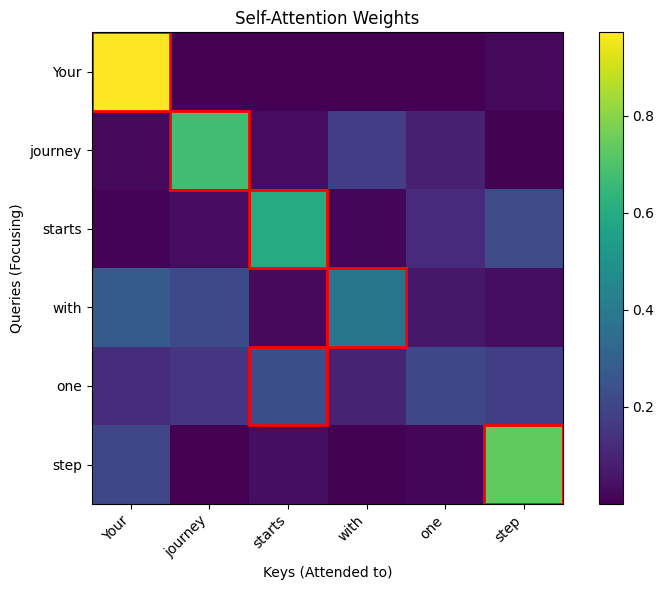

In [622]:
plot_attention_weights(attn_weights, tokens)

### Scaled Dot-Product Attention Implementation

In [623]:
def scaled_dot_product_attention(q, k, v, mask=None):
    d_k = k.size(-1)

    attn_scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)

    if mask is not None:
        attn_scores = attn_scores.masked_fill(~mask, torch.finfo(attn_scores.dtype).min)

    attn_weights = F.softmax(attn_scores, dim=-1)
    output = torch.matmul(attn_weights, v)

    return output, attn_weights


In [624]:
seq_len = inputs.size(0)

mask = torch.tril(torch.ones((seq_len, seq_len), device=inputs.device, dtype=torch.bool))

print("Causal Mask:\n", mask)

context_vecs, weights = scaled_dot_product_attention(inputs, inputs, inputs, mask)

print("\nMasked Attention Weights:\n", weights)
print("\nContext Vectors (Causal):\n", context_vecs)


Causal Mask:
 tensor([[ True, False, False, False, False, False],
        [ True,  True, False, False, False, False],
        [ True,  True,  True, False, False, False],
        [ True,  True,  True,  True, False, False],
        [ True,  True,  True,  True,  True, False],
        [ True,  True,  True,  True,  True,  True]])

Masked Attention Weights:
 tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1238, 0.8762, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0759, 0.1416, 0.7825, 0.0000, 0.0000, 0.0000],
        [0.3013, 0.2646, 0.0730, 0.3611, 0.0000, 0.0000],
        [0.1755, 0.1945, 0.2499, 0.1469, 0.2331, 0.0000],
        [0.2618, 0.0107, 0.0966, 0.0294, 0.0587, 0.5427]],
       grad_fn=<SoftmaxBackward0>)

Context Vectors (Causal):
 tensor([[-1.3351,  1.6516, -1.4236],
        [-0.7752, -0.0744,  0.8887],
        [ 0.9112,  0.0375,  0.0834],
        [-0.8670,  0.2781, -0.1414],
        [-0.0988,  0.2474,  0.0411],
        [ 0.1957,  0.9475, -1.2031]], grad_fn=<M

In [625]:
def plot_causal_attention(weights, tokens):
    weights = weights.detach().cpu()
    seq_len = len(tokens)

    plt.figure(figsize=(7, 6))
    plt.imshow(weights, cmap="viridis")
    plt.colorbar(label="Attention Weight")

    plt.xticks(range(seq_len), tokens, rotation=45, ha="right")
    plt.yticks(range(seq_len), tokens)

    plt.xlabel("Key Positions")
    plt.ylabel("Query Positions")
    plt.title("Causal Self-Attention Matrix")

    for i in range(seq_len):
        for j in range(seq_len):
            value = weights[i, j].item()
            plt.text(j, i, f"{value:.2f}",
                     ha="center", va="center",
                     color="white" if value < weights.max()/2 else "black")

    plt.tight_layout()
    plt.show()



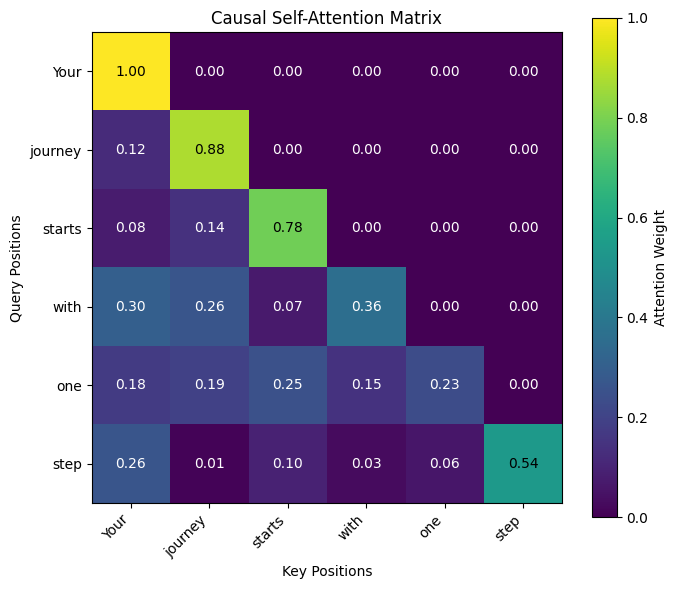

In [626]:
plot_causal_attention(weights, tokens)

In [627]:
#Should be 0 or appromately
print(weights.triu(1).max())

tensor(0., grad_fn=<MaxBackward1>)


In [628]:
#Should be 0 as well
print(weights.triu(1).sum())

tensor(0., grad_fn=<SumBackward0>)


### Trainable Attention Implementation

In [629]:
class TrainableSelfAttention(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.qkv_proj = nn.Linear(d_in, 3 * d_out, bias=qkv_bias)
        self.out_dim = d_out

    def forward(self, x, mask=None):
        # Project once, then split
        qkv = self.qkv_proj(x)
        queries, keys, values = qkv.chunk(3, dim=-1)

        # Scaled dot-product attention
        attn_scores = torch.matmul(queries, keys.transpose(-2, -1)) / math.sqrt(self.out_dim)

        if mask is not None:
            attn_scores = attn_scores.masked_fill(~mask, torch.finfo(attn_scores.dtype).min)

        attn_weights = F.softmax(attn_scores, dim=-1)
        context_vec = torch.matmul(attn_weights, values)

        return context_vec, attn_weights


In [630]:
# Initialize dimensions
d_in = 3  # Input embedding size
d_out = 2 # Output embedding size

torch.manual_seed(100)
sa_trainable = TrainableSelfAttention(d_in, d_out)

# Forward pass
context_vectors, weights = sa_trainable(inputs)

In [631]:
print("Context Vectors (Trainable):\n", context_vectors)
print("\nOutput Shape:", context_vectors.shape)

Context Vectors (Trainable):
 tensor([[ 0.0416, -0.0699],
        [ 0.0751,  0.0526],
        [ 0.1610,  0.1533],
        [ 0.1216,  0.0683],
        [ 0.1012,  0.0729],
        [ 0.1572,  0.0976]], grad_fn=<MmBackward0>)

Output Shape: torch.Size([6, 2])


In [632]:
# Check the parameter shapes
for name, param in sa_trainable.named_parameters():
    print(f"{name}: {param.shape}")

qkv_proj.weight: torch.Size([6, 3])


### Multihead Attention Implementation

In [633]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads  # Dimension per head

        # Linear projections for Q, K, V
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        # Output projection
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)

        # Register causal mask buffer (device-agnostic)
        mask = torch.triu(torch.ones(context_length, context_length), diagonal=1).bool()
        self.register_buffer("mask", mask)

    def forward(self, x):
        batch_size, seq_len, _ = x.shape

        # Project inputs to Q, K, V
        q = self.W_query(x)
        k = self.W_key(x)
        v = self.W_value(x)

        # Reshape for multi-head attention
        q = q.reshape(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.reshape(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.reshape(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

        # Scaled dot-product attention
        attn_scores = torch.matmul(q, k.transpose(-2, -1)) / (self.head_dim ** 0.5)

        # Apply causal mask
        causal_mask = self.mask[:seq_len, :seq_len]
        attn_scores = attn_scores.masked_fill(causal_mask, float("-inf"))

        # Softmax + dropout
        attn_weights = torch.softmax(attn_scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Compute context
        context = torch.matmul(attn_weights, v)
        context = context.transpose(1, 2).contiguous().reshape(batch_size, seq_len, self.d_out)

        # Final projection
        return self.out_proj(context)


In [634]:
# Create a simple batch of 2 identical sequences
batch = torch.stack([inputs, inputs], dim=0)  # (batch=2, seq_len, d_in)

# Settings
batch_size, seq_len, d_in = batch.shape
d_out = 4
num_heads = 2
context_length = 10

torch.manual_seed(100)

mha = MultiHeadAttention(
    d_in=d_in,
    d_out=d_out,
    context_length=context_length,
    dropout=0.0,
    num_heads=num_heads
)

# Forward pass (no gradients needed for inspection)
with torch.no_grad():
    output = mha(batch)

print("Input Shape :", batch.shape)
print("Output Shape:", output.shape)
print("\nMulti-Head Output (First sequence in batch):\n", output[0])


Input Shape : torch.Size([2, 6, 3])
Output Shape: torch.Size([2, 6, 4])

Multi-Head Output (First sequence in batch):
 tensor([[ 0.2383,  0.1266,  0.4548,  0.1684],
        [-0.0097, -0.0266,  0.0241,  0.1364],
        [ 0.0506, -0.1312,  0.2097,  0.0988],
        [-0.0182, -0.1032,  0.1055,  0.0853],
        [-0.0078, -0.1204,  0.1332,  0.0832],
        [ 0.0661, -0.1085,  0.2847,  0.0791]])


### Exercise 3.1: Implement Attention with Different Numbers of Heads

In [635]:
import time

In [636]:
torch.manual_seed(202)

d_in = 12
d_out = 12
context_length = 12
dropout = 0.1

batch = torch.randn(3, 6, d_in)

head_configs = [1, 3, 4, 6]

results = {}
stats = {}
times = {}


In [637]:
for num_heads in head_configs:
    print(f"Testing with {num_heads} heads...")

    torch.manual_seed(123)
    mha = MultiHeadAttention(d_in, d_out, context_length, dropout, num_heads)

    t0 = time.perf_counter()
    out = mha(batch)
    t1 = time.perf_counter()

    results[num_heads] = out.detach()
    times[num_heads] = (t1 - t0) * 1000  # ms

    # Output stats
    stats[num_heads] = {
        "head_dim": d_out // num_heads,
        "shape": tuple(out.shape),
        "mean": out.mean().item(),
        "std": out.std().item(),
        "min": out.min().item(),
        "max": out.max().item(),
        "l2_norm": out.norm().item(),
    }

    print(f"  Head Dimension: {stats[num_heads]['head_dim']}")
    print(f"  Output Shape:   {stats[num_heads]['shape']}")
    print(f"  mean/std:       {stats[num_heads]['mean']:.4f} / {stats[num_heads]['std']:.4f}")
    print(f"  min/max:        {stats[num_heads]['min']:.4f} / {stats[num_heads]['max']:.4f}")
    print(f"  L2 norm:        {stats[num_heads]['l2_norm']:.4f}")
    print(f"  time:           {times[num_heads]:.3f} ms")
    print("-" * 50)

Testing with 1 heads...
  Head Dimension: 12
  Output Shape:   (3, 6, 12)
  mean/std:       0.0212 / 0.3018
  min/max:        -0.6104 / 0.8891
  L2 norm:        4.4357
  time:           0.807 ms
--------------------------------------------------
Testing with 3 heads...
  Head Dimension: 4
  Output Shape:   (3, 6, 12)
  mean/std:       0.0203 / 0.2890
  min/max:        -0.6280 / 0.8512
  L2 norm:        4.2473
  time:           0.925 ms
--------------------------------------------------
Testing with 4 heads...
  Head Dimension: 3
  Output Shape:   (3, 6, 12)
  mean/std:       0.0172 / 0.2909
  min/max:        -0.6545 / 0.8891
  L2 norm:        4.2729
  time:           0.894 ms
--------------------------------------------------
Testing with 6 heads...
  Head Dimension: 2
  Output Shape:   (3, 6, 12)
  mean/std:       0.0248 / 0.2841
  min/max:        -0.8033 / 0.8907
  L2 norm:        4.1818
  time:           0.786 ms
--------------------------------------------------


In [638]:
base = results[1]
print("\nComparison vs 1 head baseline")
for h in head_configs:
    if h == 1:
        continue
    mse = torch.mean((results[h] - base) ** 2).item()
    cos = torch.nn.functional.cosine_similarity(
        results[h].flatten(), base.flatten(), dim=0
    ).item()
    print(f"{h} heads -> MSE: {mse:.6f}, cosine sim: {cos:.6f}")


Comparison vs 1 head baseline
3 heads -> MSE: 0.017509, cosine sim: 0.900572
4 heads -> MSE: 0.011249, cosine sim: 0.936603
6 heads -> MSE: 0.021786, cosine sim: 0.874896


### Exercise 3.2: Visualize attention patterns for different types of text (narrative, code, poetry)

In [639]:
def visualize_text_attention(text_type, tokens, inputs, mha_model):
    with torch.no_grad():
        batch_size, seq_len, d_model = inputs.shape
        device = inputs.device

        # 1. Linear projections
        k = mha_model.W_key(inputs)
        q = mha_model.W_query(inputs)

        # Reshape for single-head visualization
        k = k.reshape(batch_size, seq_len, 1, d_model).transpose(1, 2)  # (b, 1, T, d)
        q = q.reshape(batch_size, seq_len, 1, d_model).transpose(1, 2)

        # 2. Attention scores
        attn_scores = torch.matmul(q, k.transpose(-2, -1))  # (b, 1, T, T)

        # Scale
        attn_scores = attn_scores / (d_model ** 0.5)

        # 3. Causal mask
        causal_mask = torch.triu(
            torch.ones(seq_len, seq_len, device=device), diagonal=1
        ).bool()

        attn_scores = attn_scores.masked_fill(causal_mask, float("-inf"))

        # 4. Softmax
        attn_weights = torch.softmax(attn_scores, dim=-1)

        # Remove batch/head dims → (T, T)
        weights_2d = attn_weights[0, 0].cpu()

        # 5. Plot
        plt.figure(figsize=(8, 6))
        sns.heatmap(weights_2d, annot=True, cmap="Reds",
                    xticklabels=tokens, yticklabels=tokens)

        plt.title(f"Attention Pattern: {text_type}")
        plt.xlabel("Keys (Attended to)")
        plt.ylabel("Queries (Focusing)")
        plt.tight_layout()
        plt.show()


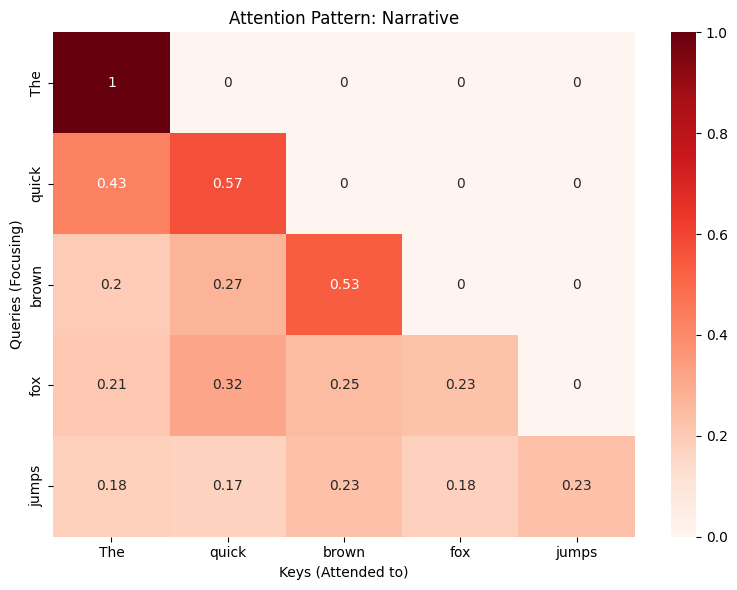

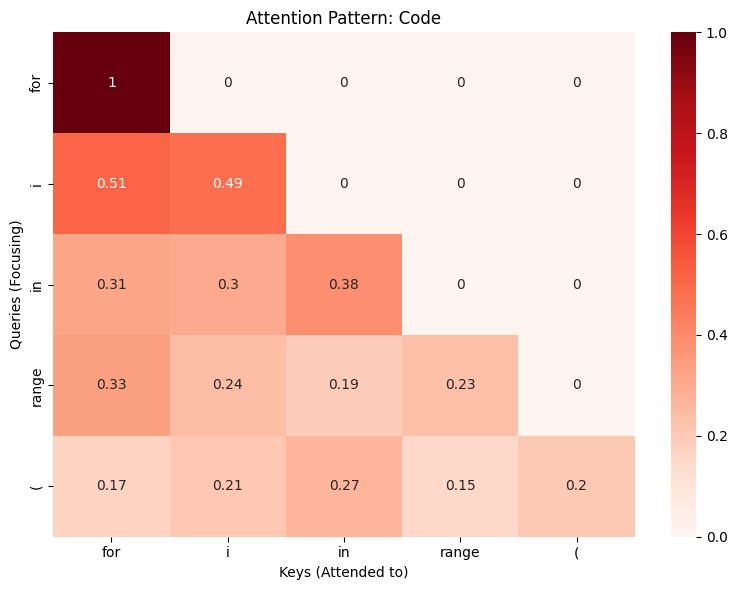

In [640]:
torch.manual_seed(42)

embed_dim = 8
seq_len = 5

# 1. Narrative text
tokens_narrative = ["The", "quick", "brown", "fox", "jumps"]
inputs_narrative = torch.randn(1, seq_len, embed_dim)  # Dummy embeddings

# 2. Code snippet
tokens_code = ["for", "i", "in", "range", "("]
inputs_code = torch.randn(1, seq_len, embed_dim)

# Initialize visualization model
mha_viz = MultiHeadAttention(
    d_in=embed_dim,
    d_out=embed_dim,
    context_length=10,
    dropout=0.0,
    num_heads=1
)

# Generate plots
visualize_text_attention("Narrative", tokens_narrative, inputs_narrative, mha_viz)
visualize_text_attention("Code", tokens_code, inputs_code, mha_viz)
